In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Dataset directory
DATASET_DIR = Path("/Users/nedamohseni/Downloads/SoLo_dataset")

Participant: participant_1
Selected start: 2021-11-12 16:50:19.393000-08:00
Selected end: 2021-11-12 16:51:19.393000-08:00
PPG samples: 1498
ACC samples: 1498


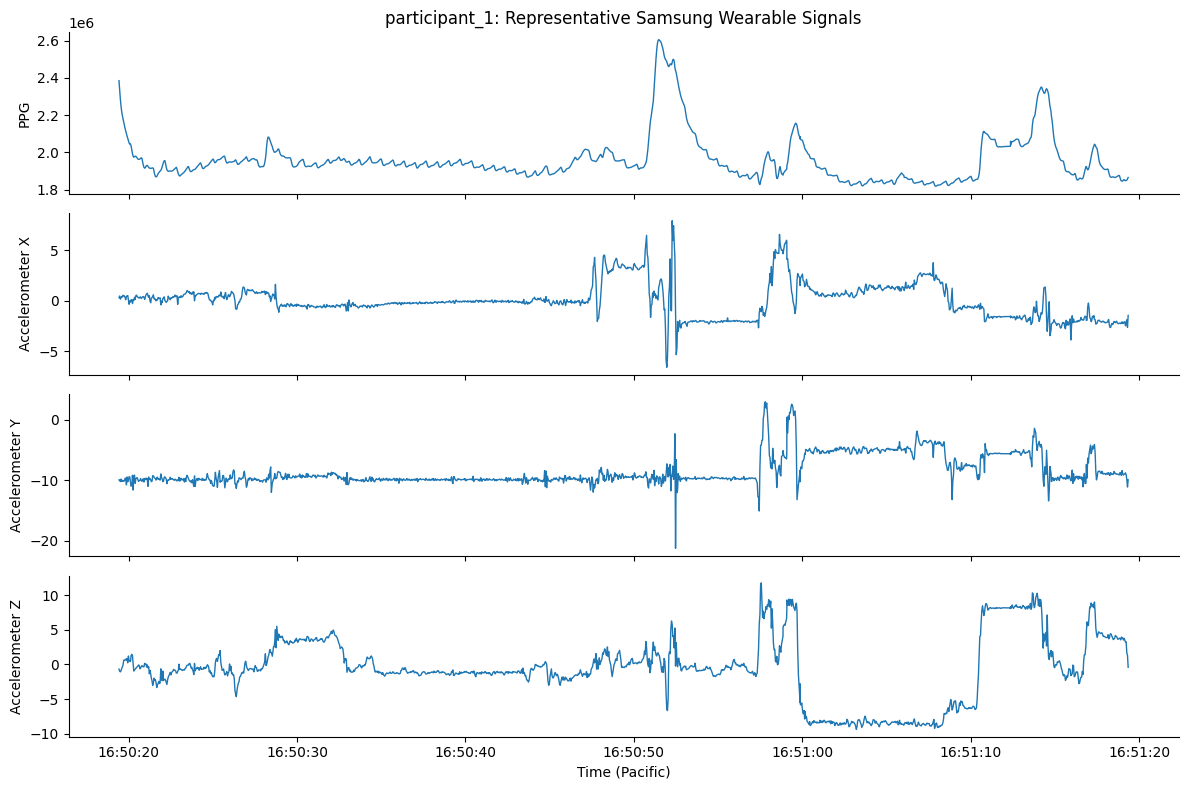

In [24]:
import matplotlib.dates as mdates

PARTICIPANT = "participant_1"
ppg_path = DATASET_DIR / PARTICIPANT / "Samsung" / "raw_ppg_hrm.csv"
acc_path = DATASET_DIR / PARTICIPANT / "Samsung" / "raw_accelerometer.csv"

# Load data
ppg = pd.read_csv(ppg_path)
acc = pd.read_csv(acc_path)

# Convert Unix milliseconds to Pacific time
ppg["datetime"] = pd.to_datetime(ppg["timestamp"], unit="ms", utc=True).dt.tz_convert("America/Los_Angeles")
acc["datetime"] = pd.to_datetime(acc["timestamp"], unit="ms", utc=True).dt.tz_convert("America/Los_Angeles")

# Sort by time
ppg = ppg.sort_values("datetime").reset_index(drop=True)
acc = acc.sort_values("datetime").reset_index(drop=True)

# Find recording sessions
gaps = ppg["datetime"].diff()
session_starts = ppg.loc[gaps.isna() | (gaps > pd.Timedelta(seconds=30)), "datetime"].reset_index(drop=True)

# Select final 60-second segment
start = session_starts.iloc[0]
selected_start = start + pd.Timedelta(minutes=30)
selected_end = selected_start + pd.Timedelta(seconds=60)

# Extract selected segment
ppg_seg = ppg[(ppg["datetime"] >= selected_start) & (ppg["datetime"] <= selected_end)].copy()
acc_seg = acc[(acc["datetime"] >= selected_start) & (acc["datetime"] <= selected_end)].copy()

# Print information
print("Participant:", PARTICIPANT)
print("Selected start:", selected_start)
print("Selected end:", selected_end)
print("PPG samples:", len(ppg_seg))
print("ACC samples:", len(acc_seg))

# Create figure
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

# PPG
axes[0].plot(ppg_seg["datetime"], ppg_seg["ppg"], linewidth=1)
axes[0].set_ylabel("PPG")
axes[0].set_title(f"{PARTICIPANT}: Representative Samsung Wearable Signals")

# Accelerometer X
axes[1].plot(acc_seg["datetime"], acc_seg["accx"], linewidth=1)
axes[1].set_ylabel("Accelerometer X")

# Accelerometer Y
axes[2].plot(acc_seg["datetime"], acc_seg["accy"], linewidth=1)
axes[2].set_ylabel("Accelerometer Y")

# Accelerometer Z
axes[3].plot(acc_seg["datetime"], acc_seg["accz"], linewidth=1)
axes[3].set_ylabel("Accelerometer Z")
axes[3].set_xlabel("Time (Pacific)")

# Format time axis
axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S", tz=selected_start.tzinfo))

# Clean formatting
for ax in axes:
    ax.tick_params(axis="both", labelsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [22]:
hrv_dfs = []

for participant_dir in sorted(DATASET_DIR.iterdir()):
    if not participant_dir.is_dir():
        continue

    hrv_file = participant_dir / "Samsung" / "hrv_5min.csv"

    if not hrv_file.exists():
        print(f"Missing HRV file: {participant_dir.name}")
        continue

    df = pd.read_csv(hrv_file)
    df["participant"] = participant_dir.name
    hrv_dfs.append(df)

hrv_df = pd.concat(hrv_dfs, ignore_index=True)

print("Participants loaded:", hrv_df["participant"].nunique())
print("Total HRV rows:", len(hrv_df))
print("\nColumns:")
print(hrv_df.columns.tolist())

hrv_df

Missing HRV file: pers2037
Missing HRV file: pers2038
Participants loaded: 29
Total HRV rows: 8699

Columns:
['participant', 'timestamp', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_SDANN1', 'HRV_SDNNI1', 'HRV_RMSSD', 'HRV_SDSD', 'HRV_CVNN', 'HRV_CVSD', 'HRV_MedianNN', 'HRV_MadNN', 'HRV_MCVNN', 'HRV_IQRNN', 'HRV_pNN50', 'HRV_pNN20', 'HRV_HTI', 'HRV_TINN', 'HRV_LF', 'HRV_HF', 'HRV_VHF', 'HRV_LFHF', 'HRV_LFn', 'HRV_HFn', 'HRV_LnHF', 'HRV_SD1', 'HRV_SD2', 'HRV_SD1SD2', 'HRV_S', 'HR']


,participant,timestamp,HRV_MeanNN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_RMSSD,HRV_SDSD,HRV_CVNN,HRV_CVSD,...,HRV_VHF,HRV_LFHF,HRV_LFn,HRV_HFn,HRV_LnHF,HRV_SD1,HRV_SD2,HRV_SD1SD2,HRV_S,HR
0,pers2001,1636800347647,1168.529412,52.471347,5.414991,52.210333,47.837076,47.931116,0.044904,0.040938,...,0.000685,1.113780,0.522690,0.469294,-3.215756,33.892417,66.138195,0.512448,7042.141682,51.2
1,pers2001,1636800347647,1197.278226,77.375675,17.682430,72.558239,66.220250,66.306247,0.064626,0.055309,...,0.000554,1.421053,0.578237,0.406907,-4.187971,46.885597,88.228306,0.531412,12995.627735,49.8
2,pers2001,1636807548319,1141.923077,NaN,50.774081,NaN,NaN,NaN,NaN,NaN,...,0.000197,NaN,0.875212,0.122204,-4.678377,NaN,NaN,0.886226,NaN,52.2
3,pers2001,1636807548319,1224.077869,127.864987,41.018396,122.538700,82.449012,82.617577,0.104458,0.067356,...,0.000157,NaN,0.813113,0.182952,-4.918855,58.419449,171.428320,0.340781,31462.258682,49.0
4,pers2001,1636814748400,1027.586207,148.863170,NaN,94.877714,113.244843,113.430554,0.144867,0.110205,...,0.000770,1.220487,0.528034,0.432642,-4.771074,80.207514,194.094532,0.413239,48907.811619,58.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8694,pers2036,1643536891831,1068.750000,43.546313,7.342531,43.356241,52.192091,52.285877,0.040745,0.048835,...,NaN,0.481052,0.306402,0.636942,-2.880122,36.971698,49.386400,0.748621,5736.231166,56.2
8695,pers2036,1643536891831,1056.625442,40.033333,8.361535,38.802103,48.217335,48.302973,0.037888,0.045633,...,NaN,0.405671,0.268797,0.662599,-2.901226,34.155360,45.019313,0.758682,4830.672474,56.8
8696,pers2036,1644645730815,842.584746,77.219931,20.251649,74.949294,69.179223,69.277383,0.091646,0.082104,...,NaN,1.135988,0.517079,0.455180,-3.115343,48.986507,97.067530,0.504664,14938.270712,71.0
8697,pers2036,1644904942785,937.460815,55.260767,16.894874,52.688329,49.506210,49.584171,0.058947,0.052809,...,0.001374,0.956284,0.475140,0.496861,-3.713866,35.061304,69.946724,0.501257,7704.515111,64.0


# Participant-Aggregated Statistics

In [27]:
participant_means = hrv_df.groupby("participant")[hrv_features].mean()

participant_stats = participant_means.agg(["count", "mean", "std", "min", "median", "max"]).T
participant_stats["Q1"] = participant_means.quantile(0.25)
participant_stats["Q3"] = participant_means.quantile(0.75)
participant_stats["IQR"] = participant_stats["Q3"] - participant_stats["Q1"]
participant_stats["lower_fence"] = participant_stats["Q1"] - 1.5 * participant_stats["IQR"]
participant_stats["upper_fence"] = participant_stats["Q3"] + 1.5 * participant_stats["IQR"]

participant_stats["n_outside"] = [((participant_means[c] < participant_stats.loc[c, "lower_fence"]) | (participant_means[c] > participant_stats.loc[c, "upper_fence"])).sum() for c in hrv_features]
participant_stats["%_outside"] = participant_stats["n_outside"] / participant_stats["count"] * 100

participant_stats = participant_stats[["count", "mean", "std", "min", "Q1", "median", "Q3", "IQR", "max", "lower_fence", "upper_fence", "n_outside", "%_outside"]]

display(participant_stats.round(3))

,count,mean,std,min,Q1,median,Q3,IQR,max,lower_fence,upper_fence,n_outside,%_outside
HRV_MeanNN,29.0,1138.773,130.074,878.510,1055.002,1106.739,1237.897,182.895,1423.216,780.660,1512.239,0,0.000
HRV_SDNN,29.0,86.103,21.809,46.860,72.916,85.280,100.173,27.257,136.780,32.030,141.059,0,0.000
HRV_SDANN1,29.0,23.687,5.942,2.245,22.183,25.085,27.830,5.647,31.841,13.712,36.300,1,3.448
HRV_SDNNI1,29.0,78.578,21.074,46.783,64.921,75.588,90.079,25.158,130.670,27.185,127.816,1,3.448
HRV_RMSSD,29.0,86.808,26.578,49.640,65.839,84.352,105.335,39.496,150.368,6.594,164.580,0,0.000
HRV_SDSD,29.0,86.965,26.624,49.728,65.954,84.495,105.562,39.608,150.645,6.543,164.974,0,0.000
HRV_CVNN,29.0,0.076,0.016,0.040,0.068,0.076,0.082,0.014,0.121,0.047,0.103,3,10.345
HRV_CVSD,29.0,0.076,0.020,0.046,0.063,0.072,0.086,0.022,0.134,0.030,0.119,2,6.897
HRV_MedianNN,29.0,1139.179,132.655,870.798,1058.418,1104.030,1243.048,184.629,1430.259,781.475,1519.991,0,0.000
HRV_MadNN,29.0,72.645,21.003,40.595,60.231,71.857,82.931,22.700,127.464,26.181,116.981,1,3.448


# selected features

In [28]:
selected_features = ["HR", "HRV_MeanNN", "HRV_SDNN", "HRV_RMSSD", "HRV_SDSD", "HRV_pNN50", "HRV_HF", "HRV_LFHF"]

participant_means = hrv_df.groupby("participant")[selected_features].mean()

participant_stats_selected = participant_means.agg(["count", "mean", "std", "min", "median", "max"]).T
participant_stats_selected["Q1"] = participant_means.quantile(0.25)
participant_stats_selected["Q3"] = participant_means.quantile(0.75)
participant_stats_selected["IQR"] = participant_stats_selected["Q3"] - participant_stats_selected["Q1"]
participant_stats_selected["lower_fence"] = participant_stats_selected["Q1"] - 1.5 * participant_stats_selected["IQR"]
participant_stats_selected["upper_fence"] = participant_stats_selected["Q3"] + 1.5 * participant_stats_selected["IQR"]

participant_stats_selected["n_outside"] = [((participant_means[c] < participant_stats_selected.loc[c, "lower_fence"]) | (participant_means[c] > participant_stats_selected.loc[c, "upper_fence"])).sum() for c in selected_features]
participant_stats_selected["%_outside"] = participant_stats_selected["n_outside"] / participant_stats_selected["count"] * 100

participant_stats_selected = participant_stats_selected[["count", "mean", "std", "min", "Q1", "median", "Q3", "IQR", "max", "lower_fence", "upper_fence", "n_outside", "%_outside"]]

display(participant_stats_selected.round(3))

,count,mean,std,min,Q1,median,Q3,IQR,max,lower_fence,upper_fence,n_outside,%_outside
HR,29.0,53.380,5.786,42.275,48.960,54.233,56.924,7.964,66.335,37.015,68.869,0,0.0
HRV_MeanNN,29.0,1138.773,130.074,878.510,1055.002,1106.739,1237.897,182.895,1423.216,780.660,1512.239,0,0.0
HRV_SDNN,29.0,86.103,21.809,46.860,72.916,85.280,100.173,27.257,136.780,32.030,141.059,0,0.0
HRV_RMSSD,29.0,86.808,26.578,49.640,65.839,84.352,105.335,39.496,150.368,6.594,164.580,0,0.0
HRV_SDSD,29.0,86.965,26.624,49.728,65.954,84.495,105.562,39.608,150.645,6.543,164.974,0,0.0
HRV_pNN50,29.0,34.405,15.962,10.551,24.582,31.686,47.400,22.818,69.765,-9.646,81.628,0,0.0
HRV_HF,29.0,0.032,0.009,0.019,0.026,0.033,0.039,0.014,0.053,0.005,0.060,0,0.0
HRV_LFHF,29.0,0.888,0.302,0.289,0.658,0.879,1.097,0.440,1.526,-0.002,1.757,0,0.0


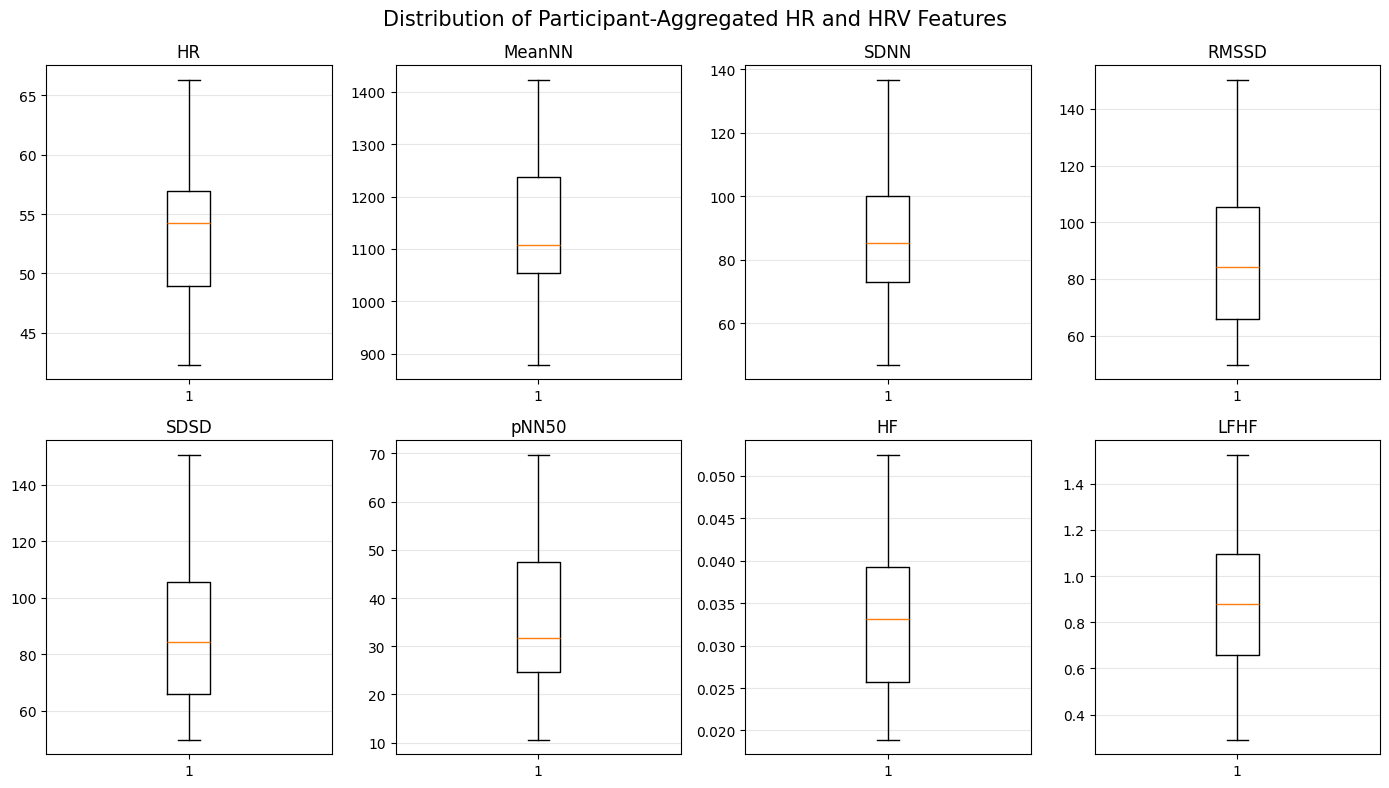

In [29]:
selected_features = ["HR", "HRV_MeanNN", "HRV_SDNN", "HRV_RMSSD", "HRV_SDSD", "HRV_pNN50", "HRV_HF", "HRV_LFHF"]

fig, axes = plt.subplots(2, 4, figsize=(14, 8))
axes = axes.flatten()

for ax, feature in zip(axes, selected_features):
    values = participant_means[feature].dropna()
    ax.boxplot(values)
    ax.set_title(feature.replace("HRV_", ""))
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Distribution of Participant-Aggregated HR and HRV Features", fontsize=15)
plt.tight_layout()
plt.show()